In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import scipy
import torch
import scipy.io as sio
from DS3Dplus.lens_utils import LensPSF
from DS3Dplus.ds3d_utils import calculate_cc
from misc import mask_resipe , show_imset
import os

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


# PSF modeling

In [2]:
# model size
N = 255  # matrix size
N_aper = 241  # aperture size

PSFs: (213, 21, 21)
display some PSFs


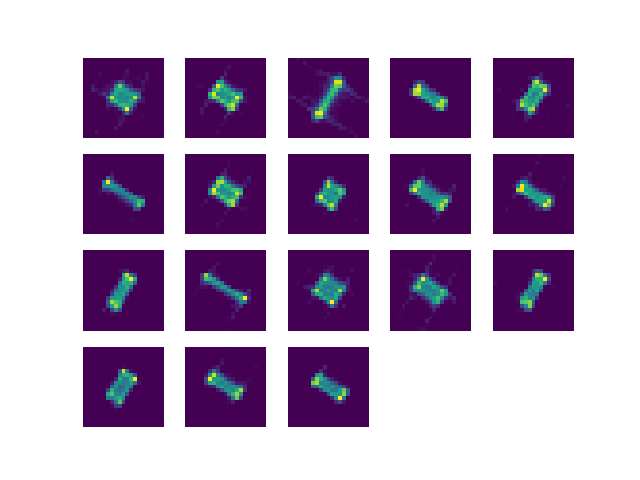

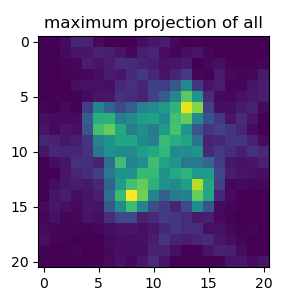

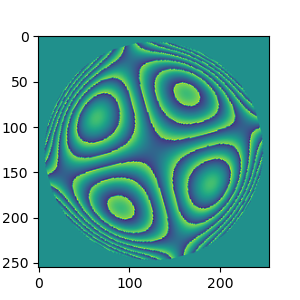

In [4]:
# # exp 16 TP
psf_measurement = np.load(os.path.join(os.getcwd(), "data", "tp_psf_collection_0101.npy"))
measured_photons = np.sum(psf_measurement, axis=(1, 2)).astype(np.float32)
measured_psf_shape = psf_measurement.shape[1:]
print(f'PSFs: {psf_measurement.shape}')
print(f'display some PSFs')
show_imset(psf_measurement[::12])
# # maximum projection of the PSF collection
plt.figure(figsize=(3, 3))
plt.imshow(np.max(psf_measurement, axis=0))
plt.title('maximum projection of all')
plt.show()

# read phase mask design and set up the mask initialization

mat_dict = sio.loadmat(os.path.join(os.getcwd(), "data", "tokina_flow_tetrapod_ps20um_607.mat"))
mask0 = mat_dict[list(mat_dict.keys())[3]]
mask0 = np.angle(np.exp(1j*mask0))
mask0 = mask_resipe(mask0, N_aper, N)
mask0 = scipy.ndimage.rotate(mask0, 105, reshape=False)

plt.figure(figsize=(3, 3))
plt.imshow(mask0)
plt.show()


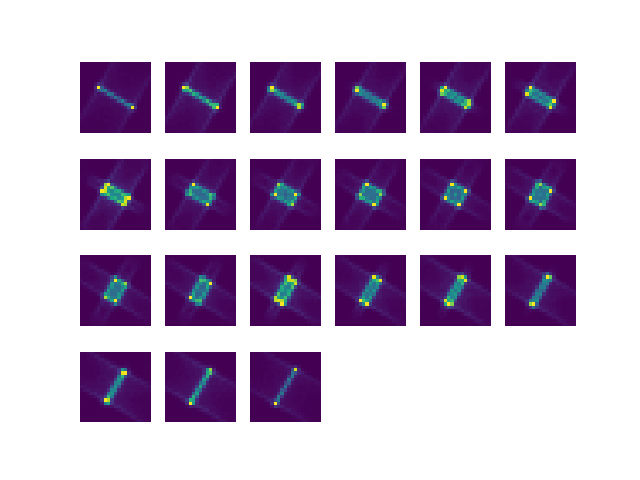

In [5]:
psf_param_dict = dict(
    device=device,
    N=N,
    N_aper=N_aper,
    im_size=measured_psf_shape,
    scaling_factor=5.0, 
    rotation_factor=0.0,
    coef_defocus=-6.5,  # negative sign, match with tomo coordinate system
    sigma0 = 1.8,  # blur kernel 
    sigma1 = 0.3,
    zrange=20+2,  # beam thickness, z range
)

# test the initialized model
model = LensPSF(psf_param_dict)

phase_mask = torch.tensor(mask0, device=device)
zrange = psf_param_dict['zrange']
num_z = 21
xyzs_test = torch.zeros((num_z, 3), device=device)
xyzs_test[:, 2] = torch.linspace(-zrange/2, zrange/2, num_z, device=device)
photons_test = torch.ones((num_z, 1), device=device) * 2e3
bgs_test = torch.zeros((num_z, 1), device=device)
psf_test = model(phase_mask, xyzs_test, photons_test, bgs_test).detach().cpu()

# show 
plt.close()
show_imset(psf_test)


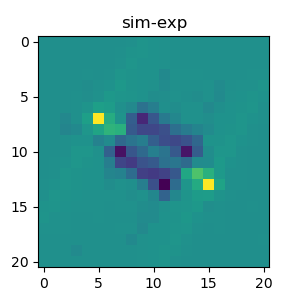

In [6]:
# initial check
test_idx = 0
img_test = psf_test[test_idx]
img_test = (img_test-img_test.min())/(img_test.max()-img_test.min())
exp_idx = 0
img_exp = psf_measurement[exp_idx]
img_exp = (img_exp-img_exp.min())/(img_exp.max()-img_exp.min())

plt.figure(figsize=(3, 3))
plt.imshow(img_test-img_exp)
plt.title('sim-exp')
plt.show()

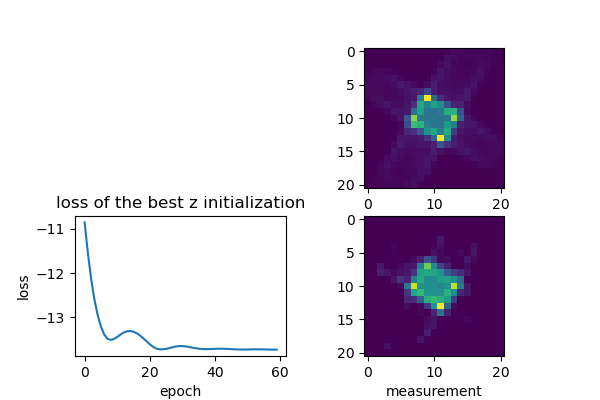

xyz estimate (xy in pixel unit): [ 0.02988087  0.06639428 -1.02975277]
photon estimate: [2997.8445]
background estimate: [0.]


In [8]:
# MLE test with z initializations
idx = exp_idx
y = torch.tensor(psf_measurement[idx], device=device).type(torch.float32)
model_in_situ = LensPSF(psf_param_dict)
mask_in_situ = torch.tensor(mask0, device=device)

xy0 = np.array([[0.0, 0.0]])
# z0_list = np.linspace(-10.0, 10.0, 3)  # z initialization options
z0_list = np.linspace(-5.0, 5.0, 2)

photons0 = 3000.0
bg0 = 0.0

num_iter = 60
loss_list = []
result_list = []

for z0 in z0_list:
    z = torch.tensor([[z0]], device=device, requires_grad=True)
    xy = torch.tensor(xy0, device=device, requires_grad=True)
    photon = torch.tensor([[photons0]], device=device, requires_grad=True)
    bg = torch.tensor([[bg0]], device=device, requires_grad=True)
    optimizer = torch.optim.Adam([{'params': xy, 'lr': 0.05},
                                  {'params': z, 'lr': 0.5},
                                  {'params': photon, 'lr': 200},
                                  # {'params': bg, 'lr': 0.1},
                                  ])
    epoch_loss = []
    for i in range(num_iter):
        xyz = torch.concat((xy, z), dim=1)
        fx = model_in_situ(mask_in_situ, xyz, photon, bg)[0]
        loss = torch.mean(fx-y*torch.log(fx))  # poisson likelihood loss
        # loss = torch.nn.functional.mse_loss(fx, y)  # mse, gaussian likelihood loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
    xyz = torch.concat((xy, z), dim=1)
    loss_list.append(epoch_loss)
    result_list.append([xyz.detach(), photon.detach(), bg.detach(), fx.detach()])
converged_losses = np.array([los[-1] for los in loss_list])
min_idx = np.argmin(converged_losses)
best_result, best_epoch_loss = result_list[min_idx], loss_list[min_idx]
xyz_hat, photon_hat, bg_hat, y_hat = best_result


plt.close()
plt.figure(figsize=(6, 4))
# plt.subplot(2, 2, 1)
# plt.plot(z0_list, converged_losses)
# plt.xlabel('z0')
# plt.ylabel('converged loss')
# plt.title('z initialization')

plt.subplot(2, 2, 3)
plt.plot(best_epoch_loss)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss of the best z initialization')

plt.subplot(2, 2, 2)
plt.imshow(y_hat.cpu())
plt.xlabel('model')

plt.subplot(2, 2, 4)
plt.imshow(y.cpu())
plt.xlabel('measurement')

plt.show()

print(f'xyz estimate (xy in pixel unit): {xyz_hat.cpu().numpy()[0]}')
print(f'photon estimate: {photon_hat.cpu().numpy()[0]}')
print(f'background estimate: {bg_hat.cpu().numpy()[0]}')


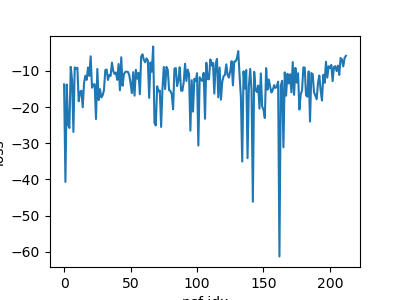

In [9]:
# apply to all measured PSFs
nz  = psf_measurement.shape[0]

xyz_hat_all, photon_hat_all, bg_hat_all, y_hat_all = [], [], [], []
best_converged_loss_all = []

for kk in range(nz):
    y = torch.tensor(psf_measurement[kk], device=device).type(torch.float32)
    
    loss_list = []
    result_list = []
    for z0 in z0_list:
        z = torch.tensor([[z0]], device=device, requires_grad=True)
        xy = torch.tensor(xy0, device=device, requires_grad=True)
        photon = torch.tensor([[photons0]], device=device, requires_grad=True)
        bg = torch.tensor([[bg0]], device=device, requires_grad=True)
        optimizer = torch.optim.Adam([{'params': xy, 'lr': 0.05},
                                      {'params': z, 'lr': 0.5},
                                      {'params': photon, 'lr': 200},
                                      # {'params': bg, 'lr': 0.1},
                                      ])
        epoch_loss = []
        for i in range(num_iter):
            xyz = torch.concat((xy, z), dim=1)
            fx = model_in_situ(mask_in_situ, xyz, photon, bg)[0]
            loss = torch.mean(fx-y*torch.log(fx))  # poisson likelihood loss
            # loss = torch.nn.functional.mse_loss(fx, y)  # mse, gaussian likelihood loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss.append(loss.item())
        xyz = torch.concat((xy, z), dim=1)
        loss_list.append(epoch_loss)
        result_list.append([xyz.detach(), photon.detach(), bg.detach(), fx.detach()])
    converged_losses = np.array([los[-1] for los in loss_list])
    min_idx = np.argmin(converged_losses)
    best_result, best_epoch_loss = result_list[min_idx], loss_list[min_idx]
    xyz_hat, photon_hat, bg_hat, y_hat = best_result
    
    xyz_hat_all.append(xyz_hat)
    photon_hat_all.append(photon_hat)
    bg_hat_all.append(bg_hat)
    y_hat_all.append(y_hat)
    best_converged_loss_all.append(best_epoch_loss[-1])


plt.figure(figsize=(4, 3))
plt.plot(best_converged_loss_all)
plt.xlabel('psf idx')
plt.ylabel('loss')
plt.show()


In [10]:
xyzs = torch.concat(xyz_hat_all, dim=0)
photons = torch.concat(photon_hat_all, dim=0)
bgs = torch.concat(bg_hat_all, dim=0)

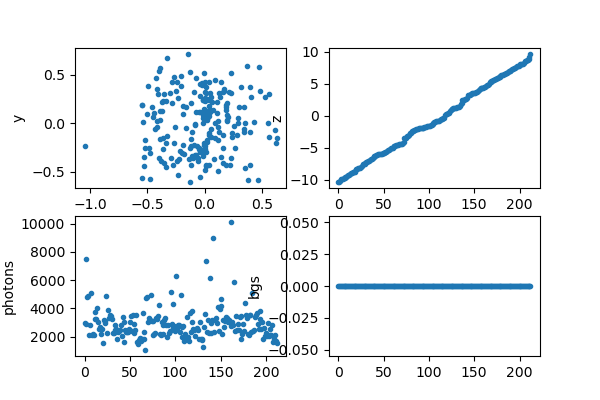

In [11]:
xyzs_np = xyzs.cpu().numpy()
photons_np = photons.cpu().numpy()
bgs_np = bgs.cpu().numpy()

plt.close()
plt.figure(figsize=(6, 4))
plt.subplot(221)
plt.plot(xyzs_np[:, 0], xyzs_np[:, 1], '.')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(222)
plt.plot(np.sort(xyzs_np[:, 2]), '.')
plt.xlabel('psf idx after sorting')
plt.ylabel('z')

plt.subplot(223)
plt.plot(photons_np, '.')
plt.ylabel('photons')

plt.subplot(224)
plt.plot(bgs_np, '.')
plt.ylabel('bgs')

plt.show()

modeling accuracy (CC): 0.9683055244937093


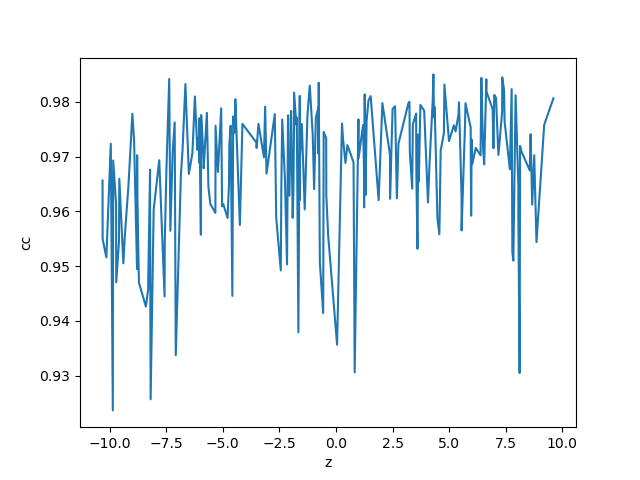

In [12]:
ccs0 = calculate_cc(psf_measurement, torch.stack(y_hat_all).cpu().numpy())
print(f'modeling accuracy (CC): {np.average(ccs0)}')
zs = xyzs_np[:, 2].copy()
sort_ids = np.argsort(zs)
zs = zs[sort_ids]

ccs0_sorted = ccs0[sort_ids].copy()
plt.figure()
plt.plot(zs, ccs0_sorted)
plt.xlabel('z')
plt.ylabel('cc')
plt.show()

In [13]:
from torch.utils.data import Dataset, DataLoader
class MyDataset(Dataset):
    # initialization of the dataset
    def __init__(self, xyzs, photons, bgs, y):
        self.xyzs = xyzs
        self.photons = photons
        self.bgs = bgs
        self.y = y

    # total number of samples in the dataset
    def __len__(self):
        return len(xyzs)

    # sampling one example from the data
    def __getitem__(self, index):
        
        xyz = self.xyzs[index]
        photon = self.photons[index]
        bg = self.bgs[index]
        y = self.y[index]
        
        return xyz, photon, bg, y
    
def tv_func(mask):
    tv = torch.mean(torch.abs(mask[:-1, :]-mask[1:, :]))+torch.mean(torch.abs(mask[:, :-1]-mask[:, 1:]))
    return tv

In [14]:
# apply z range constraint
zrange = psf_param_dict['zrange'] # mm
xyzs[:, 2] = xyzs[:, 2]*zrange/(torch.max(xyzs[:, 2])-torch.min(xyzs[:, 2]))


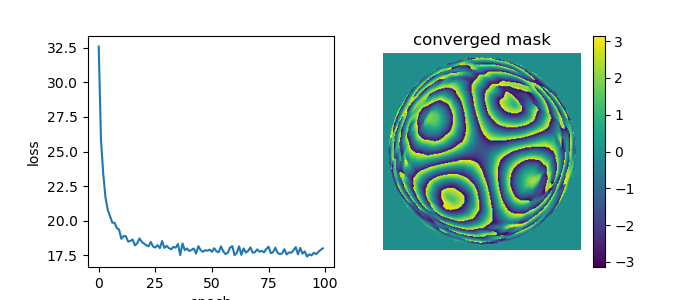

In [15]:
mask_in_situ = torch.tensor(mask0, device=device, requires_grad=True)

ys = torch.tensor(psf_measurement.copy(), device=device).type(torch.float32)
train_ds = MyDataset(xyzs, photons, bgs, ys)
# train_ds = MyDataset(xyzs, torch.from_numpy(measured_photons[:, np.newaxis]).to(device), bgs, ys)

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
optimizer = torch.optim.Adam([{'params': mask_in_situ, 'lr': 0.3},
                              ])
epoch_loss = []
for i in range(100):
    batch_loss = []
    for xyzs_batch, photons_batch, bgs_batch, ys_batch in train_dl:
        fx = model_in_situ(mask_in_situ, xyzs_batch, photons_batch, bgs_batch)
        # loss = torch.mean(fx-ys_batch*torch.log(fx))# +tv_func(mask_in_situ)*0.0
        loss = torch.nn.functional.mse_loss(fx, ys_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_loss.append(loss.item())
    epoch_loss.append(sum(batch_loss)/len(batch_loss))

mask_show = mask_in_situ.detach().cpu().numpy()
mask_show = np.angle(np.exp(1j*mask_show))   

plt.close()
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
plt.plot(epoch_loss)
plt.xlabel('epoch')
plt.ylabel('loss')

plt.subplot(1, 2, 2)
plt.imshow(mask_show)
plt.title('converged mask')
plt.colorbar()
plt.axis('off')
plt.show()

# start iteration


xyz: [ 0.02988086  0.06639425 -1.13693748], photon: [2997.8447], bg: [0.]


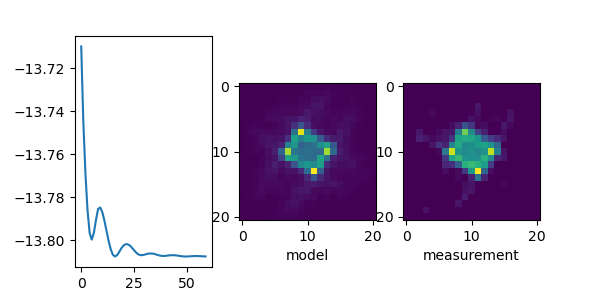

xyz: [[ 0.02550938 -0.06756677 -1.02129956]], photon: [[2538.1145]], bg: [[0.]]


In [16]:
kk = 0  # test on one PSF
print(f'xyz: {xyzs[kk].cpu().numpy()}, photon: {photons[kk].cpu().numpy()}, bg: {bgs[kk].cpu().numpy()}')

y = torch.tensor(psf_measurement[kk], device=device).type(torch.float32)
z = torch.clone(xyzs[kk:kk+1, 2:3]).requires_grad_()
xy = torch.clone(xyzs[kk:kk+1, :2]).requires_grad_()
photon = torch.clone(photons[kk:kk+1, :]).requires_grad_()
bg = torch.clone(bgs[kk:kk+1, :]).requires_grad_()
optimizer = torch.optim.Adam([{'params': xy, 'lr': 0.01},
                              {'params': z, 'lr': 0.1},
                              {'params': photon, 'lr': 100.0},
                              # {'params': bg, 'lr': 0.1},
                              ])
epoch_loss = []
for i in range(num_iter):
    xyz = torch.concat((xy, z), dim=1)
    fx = model_in_situ(mask_in_situ, xyz, photon, bg)[0]
    loss = torch.mean(fx-y*torch.log(fx))
    # loss = torch.nn.functional.mse_loss(fx, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epoch_loss.append(loss.item())
xyz = torch.concat((xy, z), dim=1)


plt.close()
plt.figure(figsize=(6, 3))
plt.subplot(1, 3, 1)
plt.plot(epoch_loss)

plt.subplot(1, 3, 2)
plt.imshow(fx.detach().cpu())
plt.xlabel('model')

plt.subplot(1, 3, 3)
plt.imshow(y.cpu())
plt.xlabel('measurement')

plt.show()

print(f'xyz: {xyz.detach().cpu().numpy()}, photon: {photon.detach().cpu().numpy()}, bg: {bg.detach().cpu().numpy()}')

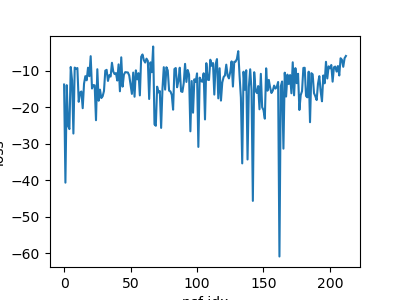

In [17]:
nz  = psf_measurement.shape[0]
converged_loss_all = []

for kk in range(nz):
    
    y = torch.tensor(psf_measurement[kk], device=device).type(torch.float32)
    z = torch.clone(xyzs[kk:kk+1, 2:3]).requires_grad_()
    xy = torch.clone(xyzs[kk:kk+1, :2]).requires_grad_()
    photon = torch.clone(photons[kk:kk+1, :]).requires_grad_()
    bg = torch.clone(bgs[kk:kk+1, :]).requires_grad_()
    optimizer = torch.optim.Adam([{'params': xy, 'lr': 0.01},
                                  {'params': z, 'lr': 0.1},
                                  {'params': photon, 'lr': 100.0},
                                  # {'params': bg, 'lr': 0.1},
                                  ])
    epoch_loss = []
    for i in range(num_iter):
        xyz = torch.concat((xy, z), dim=1)
        fx = model_in_situ(mask_in_situ, xyz, photon, bg)[0]
        loss = torch.mean(fx-y*torch.log(fx))
        # loss = torch.nn.functional.mse_loss(fx, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
    xyz = torch.concat((xy, z), dim=1)
    
    converged_loss_all.append(epoch_loss[-1])
    # update xyzs, photons, bgs
    xyzs[kk, :] = xyz.detach()
    photons[kk, :] = photon.detach()
    bgs[kk, :] = bg.detach()

plt.figure(figsize=(4, 3))
plt.plot(converged_loss_all)
plt.xlabel('psf idx')
plt.ylabel('loss')
plt.show()


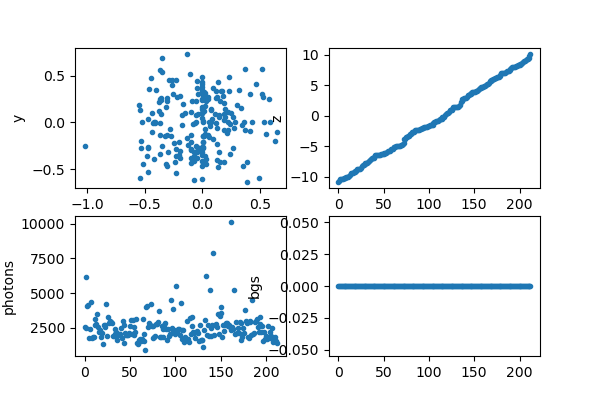

In [18]:
xyzs_np = xyzs.cpu().numpy()
photons_np = photons.cpu().numpy()
bgs_np = bgs.cpu().numpy()

plt.close()
plt.figure(figsize=(6, 4))
plt.subplot(221)
plt.plot(xyzs_np[:, 0], xyzs_np[:, 1], '.')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(222)
plt.plot(np.sort(xyzs_np[:, 2]), '.')
plt.xlabel('psf idx after sorting')
plt.ylabel('z')

plt.subplot(223)
plt.plot(photons_np, '.')
plt.ylabel('photons')

plt.subplot(224)
plt.plot(bgs_np, '.')
plt.ylabel('bgs')

plt.show()

In [19]:
# apply z range constraint
xyzs[:, 2] = xyzs[:, 2]*zrange/(torch.max(xyzs[:, 2])-torch.min(xyzs[:, 2]))


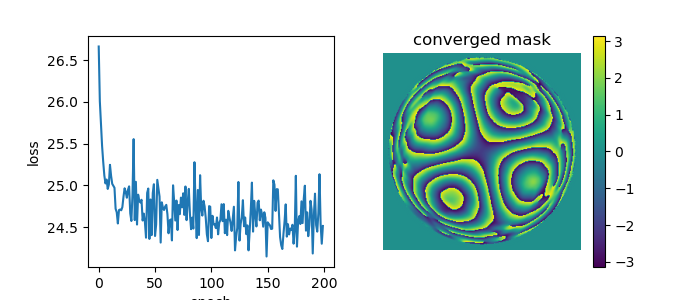

In [20]:
ys = torch.tensor(psf_measurement.copy(), device=device).type(torch.float32)
train_ds = MyDataset(xyzs, photons, bgs, ys)
# train_ds = MyDataset(xyzs, torch.from_numpy(measured_photons[:, np.newaxis]).to(device), bgs, ys)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
optimizer = torch.optim.Adam([{'params': mask_in_situ, 'lr': 0.15},
                              ])
epoch_loss = []
for i in range(200):
    batch_loss = []
    for xyzs_batch, photons_batch, bgs_batch, ys_batch in train_dl:
        fx = model_in_situ(mask_in_situ, xyzs_batch, photons_batch, bgs_batch)
        # loss = torch.mean(fx-ys_batch*torch.log(fx))
        loss = torch.nn.functional.mse_loss(fx, ys_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_loss.append(loss.item())
    epoch_loss.append(sum(batch_loss)/len(batch_loss))


# optimizer = torch.optim.Adam([{'params': mask_in_situ, 'lr': 0.1}])
# for i in range(150):
#     with torch.no_grad():
#         fx = model_in_situ(mask_in_situ, xyzs, photons, bgs)
#         model_psfs = fx.detach().cpu().numpy()
#         ccs = calculate_cc(psf_measurement, model_psfs)
#         ids = np.argsort(ccs)[:10]
        
#     fx = model_in_situ(mask_in_situ, xyzs[ids], photons[ids], bgs[ids])
#     loss = torch.nn.functional.mse_loss(fx, ys[ids])
#     # loss = torch.mean(fx-ys[ids]*torch.log(fx))
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()
#     epoch_loss.append(loss.item())


with torch.no_grad():
    fx = model_in_situ(mask_in_situ, xyzs, photons, bgs)
    model_psfs = fx.detach().cpu().numpy()
    ccs = calculate_cc(psf_measurement, model_psfs)

mask_show = mask_in_situ.detach().cpu().numpy()
mask_show = np.angle(np.exp(1j*mask_show))   

plt.close()
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
plt.plot(epoch_loss)
plt.xlabel('epoch')
plt.ylabel('loss')

plt.subplot(1, 2, 2)
plt.imshow(mask_show)
plt.title('converged mask')
plt.colorbar()
plt.axis('off')
plt.show()



modeling accuracy (CC): 0.9704297220096343


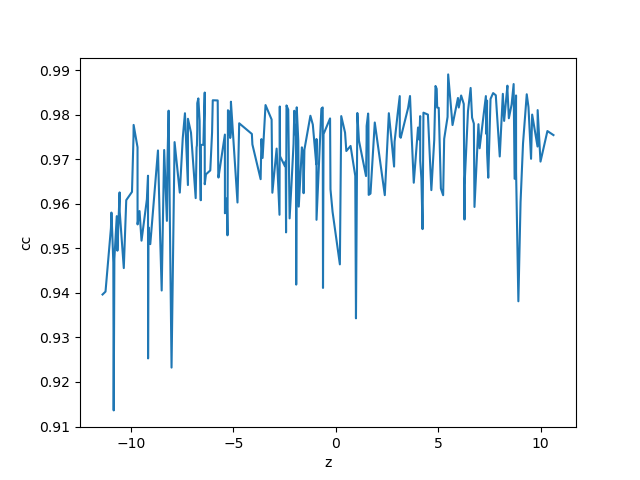

In [21]:
print(f'modeling accuracy (CC): {np.average(ccs)}')

zs = xyzs[:, 2].cpu().numpy()

sort_ids = np.argsort(zs)
zs = zs[sort_ids]
ccs_sorted = ccs[sort_ids].copy()
plt.figure()
plt.plot(zs, ccs_sorted)
plt.xlabel('z')
plt.ylabel('cc')
plt.show()


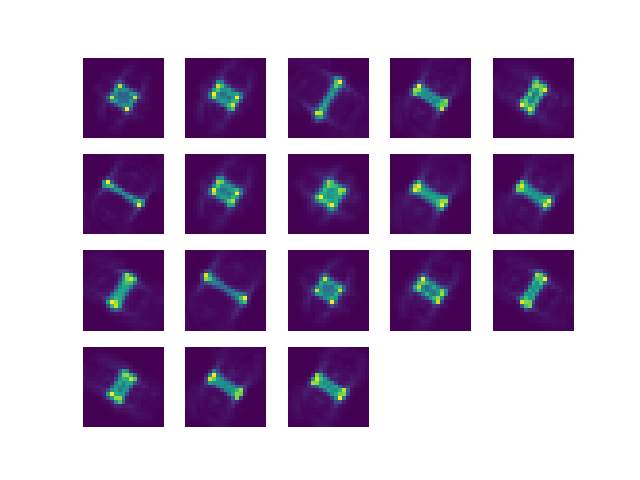

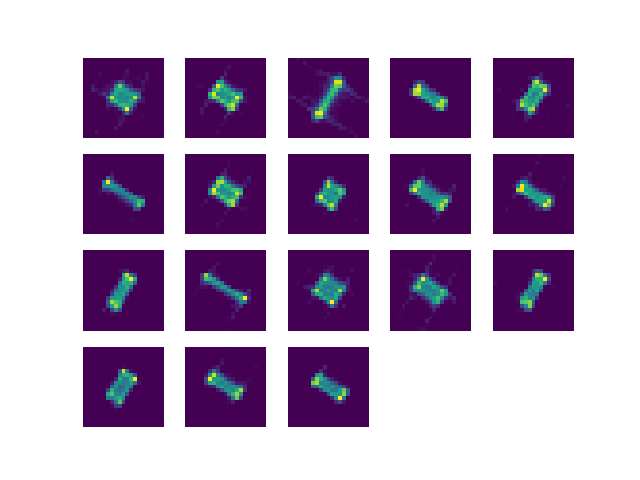

In [22]:
show_imset(model_psfs[::12])
show_imset(psf_measurement[::12])    

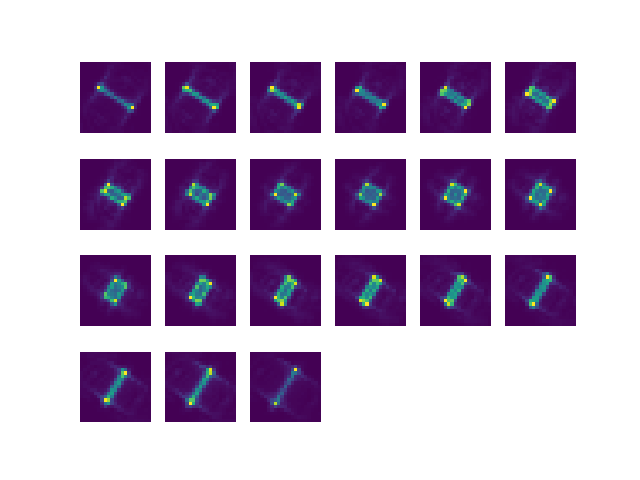

In [23]:
with torch.no_grad():
    num_z = 21
    xyzs_test = torch.zeros((num_z, 3), device=device)
    xyzs_test[:, 2] = torch.linspace(-11.0, 11.5, num_z, device=device)
    photons_test = torch.ones((num_z, 1), device=device) * 1e3
    bgs_test = torch.zeros((num_z, 1), device=device)
    
    
    psf_test = model_in_situ(mask_in_situ, xyzs_test, photons_test, bgs_test)

    plt.close()
    show_imset(psf_test.cpu())

# end the iteration 

# save the model

In [25]:

# param_file = 'model_dict_tp16_0126.npy'
# np.save(param_file, psf_param_dict)

